Preprocessing

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt

1.4.1. بررسی داده ها

In [24]:
DATA_FILE = "../greenhouse_dataset_with_status.csv"


def load_data(file_path=DATA_FILE):
    df = pd.read_csv(file_path)
    return df


def generate_data_report(df):
    print("\n")
    print("گزارش وضعیت داده‌ها")
    print(f"تعداد کل رکوردها: {len(df)}")
    print(f"تعداد کل ویژگی‌ها: {len(df.columns)}")
    print(f"تعداد کلاس‌های هدف: {df['status'].nunique()}")
    print("\nتوزیع کلاس‌ها:")
    print(df['status'].value_counts())


#  مقادیر گمشده در هر ستون
def show_missing_per_column(df):
    print("\n")
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print("مقادیر گمشده در هر ستون")
    if len(missing) > 0:
        for col, val in missing.items():
            print(f"  {col}: {val} مقدار گمشده")
    else:
        print("هیچ مقدار گمشده‌ای وجود ندارد.")


def show_column_types(df):  #نوع داده ستون‌ها (عددی در مقابل غیرعددی)
    print("\n")
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
    print(f"ستون‌های عددی ({len(numeric_cols)}): {numeric_cols}")
    print(f"ستون‌های غیرعددی ({len(categorical_cols)}): {categorical_cols}")


def plot_feature_distributions(df, numeric_cols=None, figsize=(15, 10)):
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

    n_cols = len(numeric_cols)
    n_rows = (n_cols + 3) // 4  # 4 نمودار در هر ردیف
    fig, axes = plt.subplots(n_rows, 4, figsize=figsize)
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols > 0 else []
    for i, col in enumerate(numeric_cols):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel('مقدار')
        axes[i].set_ylabel('تعداد')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

1.4.2. مدیریت مقادیر گمشده

In [25]:
#  مقادیر گمشده با روش جایگزینی
def check_and_handle_missing(df):
    total_missing = df.isnull().sum().sum()
    if total_missing == 0:
        print("هیچ مقدار گمشده‌ای وجود ندارد.")
        return df

    print(f" تعداد کل مقادیر گمشده: {total_missing}")

    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['int64', 'float64']:
                df[col] = df[col].fillna(df[col].mean(), inplace=False)
                # df[col].fillna(df[col].mean(), inplace=True)  # جایگزینی با مقادیر عددی میانگین
                print(f"  - {col}: پر شد با میانگین ({df[col].mean():.2f})")
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)  # جایگزینی با مد
                print(f"  - {col}: پر شد با مد ({df[col].mode()[0]})")
    return df

1.4.3. تبدیل ویژگی های غیرعددی

In [26]:
def encode_categorical_features(df, categorical_cols):
    df = df.copy()
    encoder = OneHotEncoder(sparse_output=False, drop='first')
    encoded_array = encoder.fit_transform(df[categorical_cols])
    encoded_df = pd.DataFrame(
        encoded_array,
        columns=encoder.get_feature_names_out(categorical_cols),
        index=df.index
    )
    df = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)
    return df, encoder

1.4.4. تبدیل برچسب خروجی

In [27]:
def encode_target(df, target_col='status'):
    mapping = {'Good': 0, 'Acceptable': 1, 'Poor': 2}
    df[target_col] = df[target_col].str.strip().map(mapping)
    return df

1.4.5. تقسیم داده ها

In [28]:
#  تقسیم داده (Stratified)
def stratified_split_train_val_test(X, y, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_state=42):
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=(1 - train_ratio), random_state=random_state,
                                                        stratify=y)
    val_test_ratio = val_ratio / (val_ratio + test_ratio)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(1 - val_test_ratio),
                                                    random_state=random_state, stratify=y_temp)
    print(
        f"\n تقسیم داده: آموزش {len(X_train)} ({train_ratio * 100:.0f}%) ، اعتبارسنجی {len(X_val)} ({val_ratio * 100:.0f}%) ، آزمون {len(X_test)} ({test_ratio * 100:.0f}%)")
    return X_train, X_val, X_test, y_train, y_val, y_test


def show_class_distribution(y, name="داده"):
    print(f"\nتوزیع کلاس‌ها در {name}:")
    print(y.value_counts())
    print(f"جمع: {len(y)}")


def show_class_distribution_after_split(y_train, y_val, y_test):
    print("توزیع کلاس‌ها بعد از تقسیم سه‌بخشی")
    show_class_distribution(y_train, "آموزش")
    show_class_distribution(y_val, "اعتبارسنجی")
    show_class_distribution(y_test, "آزمون")

1.4.6. نرمال سازی ویژگی ها

In [29]:
def normalize_features(X_train, X_val, X_test, numerical_cols):
    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_val_scaled[numerical_cols] = scaler.transform(X_val[numerical_cols])
    X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

    return X_train_scaled, X_val_scaled, X_test_scaled, scaler

اجرای پیش پردازش داده ها



گزارش وضعیت داده‌ها
تعداد کل رکوردها: 3000
تعداد کل ویژگی‌ها: 12
تعداد کلاس‌های هدف: 3

توزیع کلاس‌ها:
status
Acceptable    1500
Poor           750
Good           750
Name: count, dtype: int64


مقادیر گمشده در هر ستون
  H_out: 73 مقدار گمشده
  L: 71 مقدار گمشده
  Solar: 93 مقدار گمشده
  CO2: 100 مقدار گمشده
  Wind: 79 مقدار گمشده
  E: 92 مقدار گمشده


ستون‌های عددی (10): ['T_in', 'T_out', 'H_in', 'H_out', 'L', 'Solar', 'CO2', 'Wind', 'N', 'E']
ستون‌های غیرعددی (2): ['W', 'status']


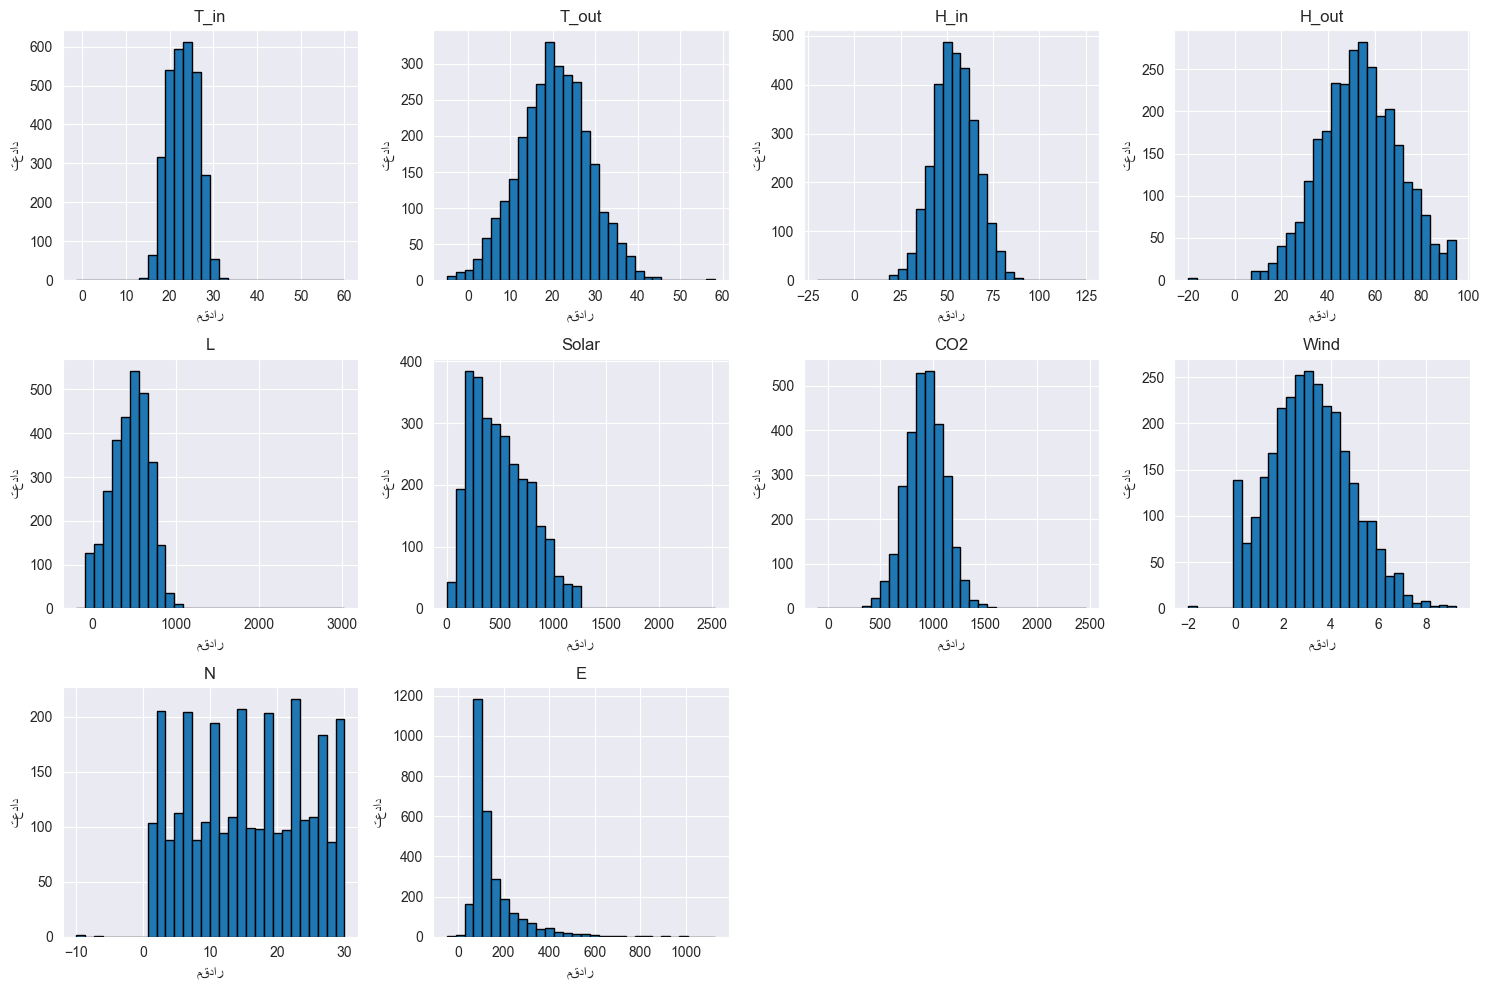

 تعداد کل مقادیر گمشده: 508
  - H_out: پر شد با میانگین (53.82)
  - L: پر شد با میانگین (448.61)
  - Solar: پر شد با میانگین (505.50)
  - CO2: پر شد با میانگین (929.67)
  - Wind: پر شد با میانگین (3.16)
  - E: پر شد با میانگین (150.67)

 تقسیم داده: آموزش 2099 (70%) ، اعتبارسنجی 450 (15%) ، آزمون 451 (15%)
توزیع کلاس‌ها بعد از تقسیم سه‌بخشی

توزیع کلاس‌ها در آموزش:
status
1    1049
0     525
2     525
Name: count, dtype: int64
جمع: 2099

توزیع کلاس‌ها در اعتبارسنجی:
status
1    225
2    113
0    112
Name: count, dtype: int64
جمع: 450

توزیع کلاس‌ها در آزمون:
status
1    226
0    113
2    112
Name: count, dtype: int64
جمع: 451


In [30]:
df = load_data()
generate_data_report(df)
show_missing_per_column(df)
show_column_types(df)
plot_feature_distributions(df)

df = check_and_handle_missing(df)

df, onehot_encoder = encode_categorical_features(df, ['W'])

df = encode_target(df)

X = df.drop(columns=['status'])
y = df['status']
X_train, X_val, X_test, y_train, y_val, y_test = stratified_split_train_val_test(X, y)
show_class_distribution_after_split(y_train, y_val, y_test)

numerical_cols = ['T_in', 'T_out', 'H_in', 'H_out', 'L', 'Solar', 'CO2', 'Wind', 'N', 'E']
X_train, X_val, X_test, scaler = normalize_features(X_train, X_val, X_test, numerical_cols)

In [31]:
import numpy as np

np.save('preprocessing/X_train.npy', X_train)
np.save('preprocessing/X_val.npy', X_val)
np.save('preprocessing/X_test.npy', X_test)
np.save('preprocessing/y_train.npy', y_train)
np.save('preprocessing/y_val.npy', y_val)
np.save('preprocessing/y_test.npy', y_test)
